 <span style="font-size: 40px;">Student Performance Analysis using Data Analytics</span>

 <span style="font-size: 20px;">Importing Required Libraries</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 <span style="font-size: 20px;">Loading the Dataset</span>

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")  

 <span style="font-size: 20px;">Dataset Overview and Information</span>

In [3]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0 

In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 

 <span style="font-size: 20px;">Data Cleaning and Handling Missing Values</span>

In [5]:
cat_cols = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
plt.rcParams.update({
    "font.size": 12,        # overall text
    "axes.titlesize": 14,   # titles
    "axes.labelsize": 12,   # axis labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

 <span style="font-size: 20px;">Exploratory Data Analysis (EDA)</span>

 <span style="font-size: 20px;">Distribution of Key Variables</span>

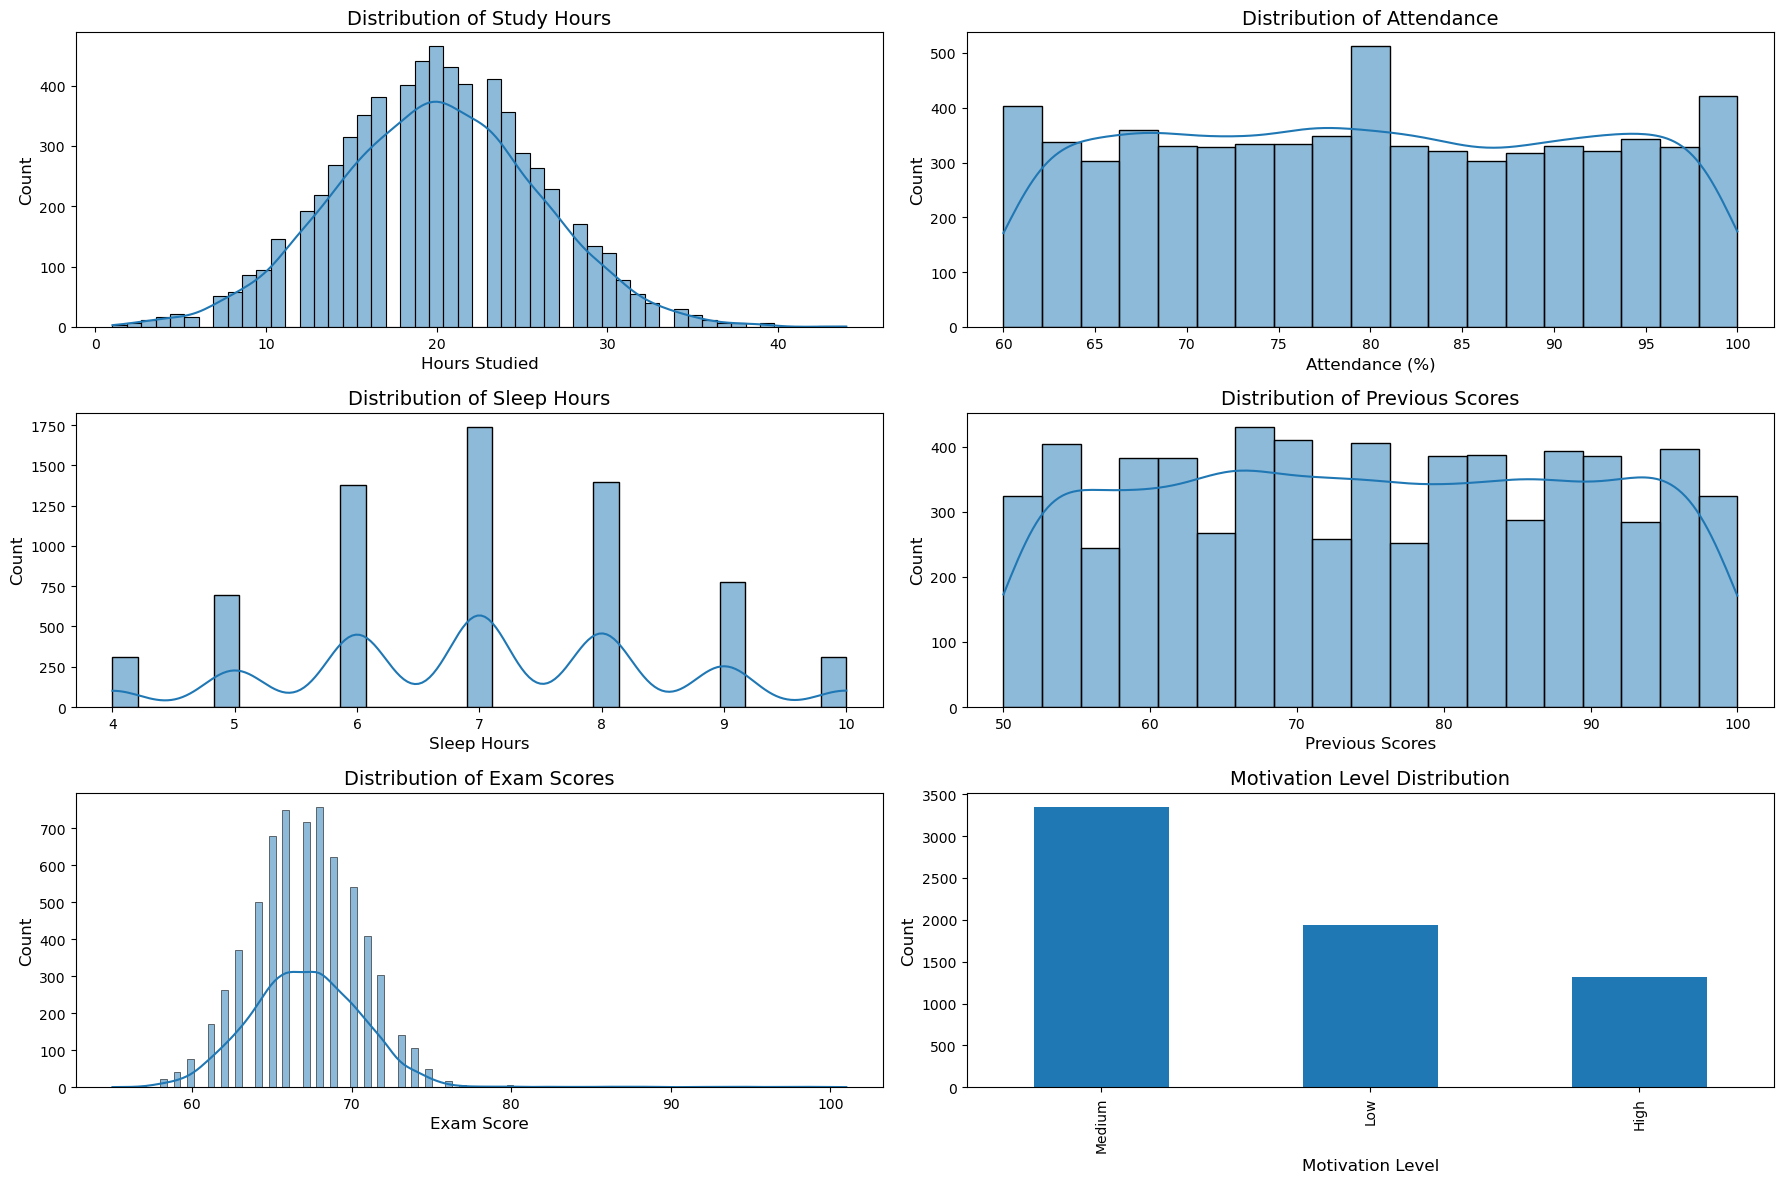

In [7]:
plt.figure(figsize=(18,12))

# Study Hours
plt.subplot(3,2,1)
sns.histplot(df["Hours_Studied"], kde=True)
plt.title("Distribution of Study Hours")
plt.xlabel("Hours Studied")
plt.ylabel("Count")

# Attendance
plt.subplot(3,2,2)
sns.histplot(df["Attendance"], kde=True)
plt.title("Distribution of Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Count")

# Sleep Hours
plt.subplot(3,2,3)
sns.histplot(df["Sleep_Hours"], kde=True)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Count")

# Previous Scores
plt.subplot(3,2,4)
sns.histplot(df["Previous_Scores"], kde=True)
plt.title("Distribution of Previous Scores")
plt.xlabel("Previous Scores")
plt.ylabel("Count")

# Exam Score
plt.subplot(3,2,5)
sns.histplot(df["Exam_Score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")

# Motivation Level
plt.subplot(3,2,6)
df["Motivation_Level"].value_counts().plot(kind="bar")
plt.title("Motivation Level Distribution")
plt.xlabel("Motivation Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

 <span style="font-size: 20px;">Relationship Between Features and Exam Score</span>

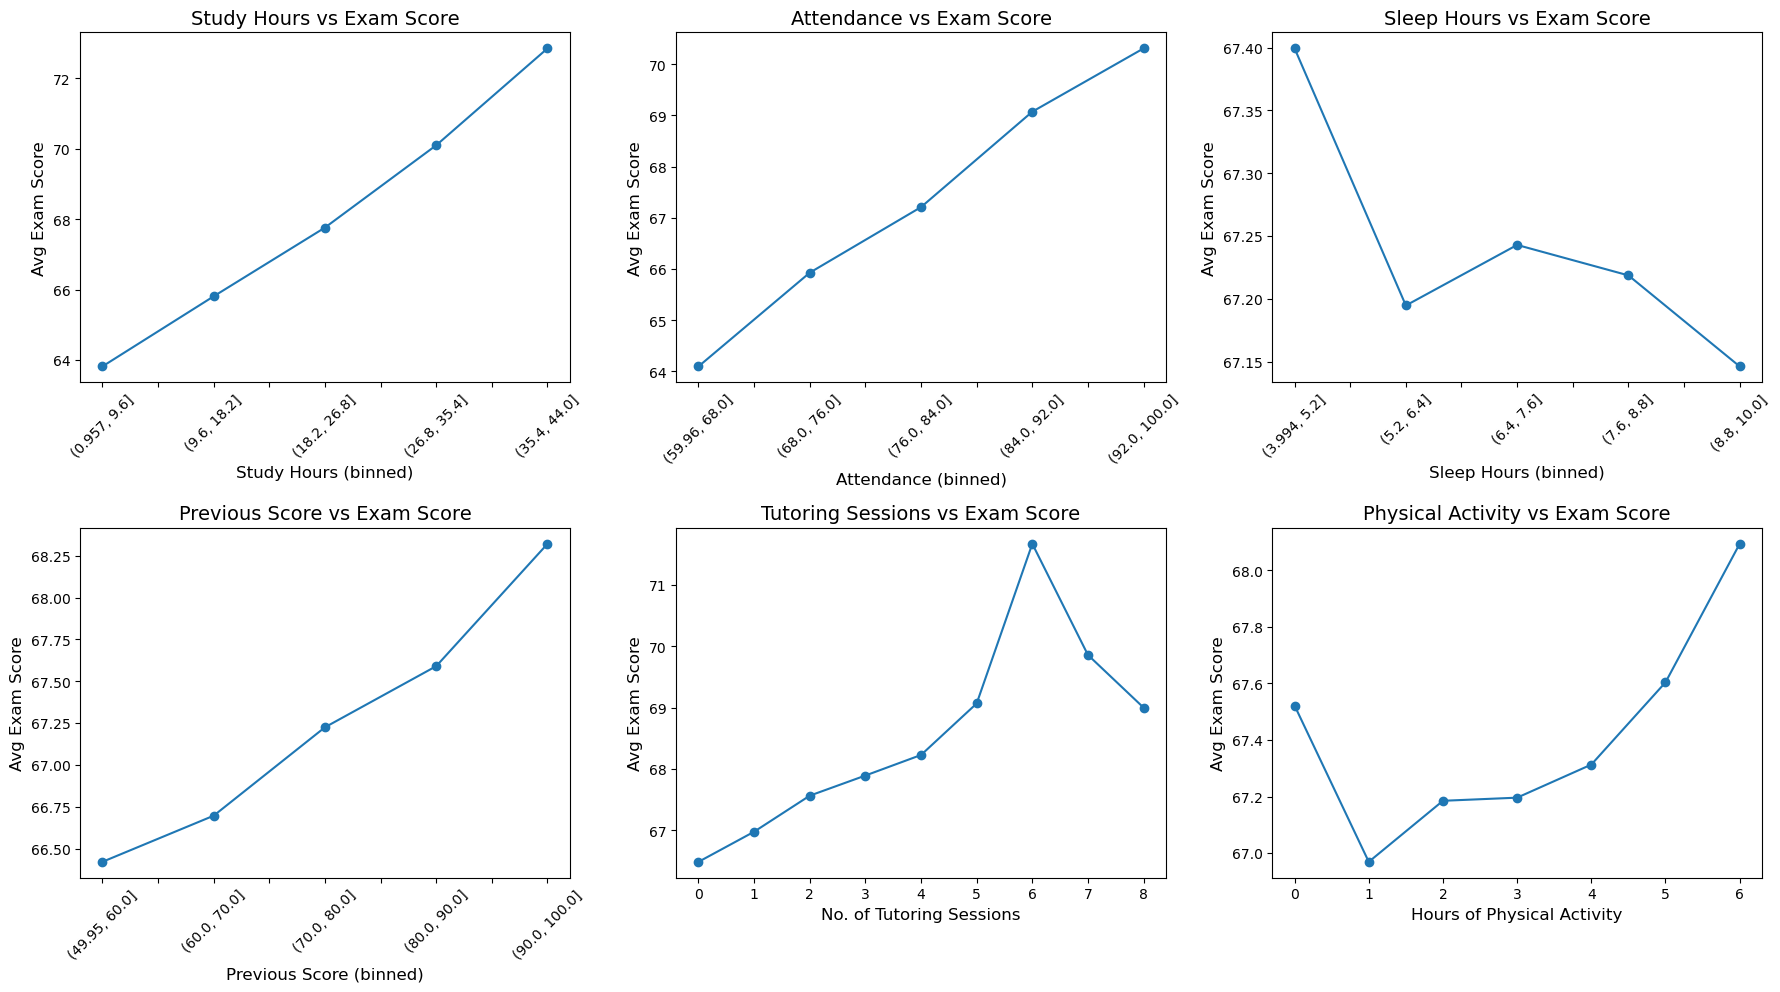

In [8]:
plt.figure(figsize=(18,14))

df["study_bins"] = pd.cut(df["Hours_Studied"], bins=5)
df["attendance_bins"] = pd.cut(df["Attendance"], bins=5)
df["sleep_bins"] = pd.cut(df["Sleep_Hours"], bins=5)
df["prev_bins"] = pd.cut(df["Previous_Scores"], bins=5)

# Study
plt.subplot(3,3,1)
df.groupby("study_bins", observed=True)["Exam_Score"].mean().plot(marker="o")
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours (binned)")
plt.ylabel("Avg Exam Score")
plt.xticks(rotation=45)

# Attendance
plt.subplot(3,3,2)
df.groupby("attendance_bins", observed=True)["Exam_Score"].mean().plot(marker="o")
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (binned)")
plt.ylabel("Avg Exam Score")
plt.xticks(rotation=45)

# Sleep
plt.subplot(3,3,3)
df.groupby("sleep_bins", observed=True)["Exam_Score"].mean().plot(marker="o")
plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours (binned)")
plt.ylabel("Avg Exam Score")
plt.xticks(rotation=45)

# Previous Score
plt.subplot(3,3,4)
df.groupby("prev_bins", observed=True)["Exam_Score"].mean().plot(marker="o")
plt.title("Previous Score vs Exam Score")
plt.xlabel("Previous Score (binned)")
plt.ylabel("Avg Exam Score")
plt.xticks(rotation=45)

# Tutoring
plt.subplot(3,3,5)
df.groupby("Tutoring_Sessions")["Exam_Score"].mean().plot(marker="o")
plt.title("Tutoring Sessions vs Exam Score")
plt.xlabel("No. of Tutoring Sessions")
plt.ylabel("Avg Exam Score")

# Physical Activity
plt.subplot(3,3,6)
df.groupby("Physical_Activity")["Exam_Score"].mean().plot(marker="o")
plt.title("Physical Activity vs Exam Score")
plt.xlabel("Hours of Physical Activity")
plt.ylabel("Avg Exam Score")

plt.tight_layout()
plt.show()

 <span style="font-size: 20px;">Correlation and Density Analysis</span>

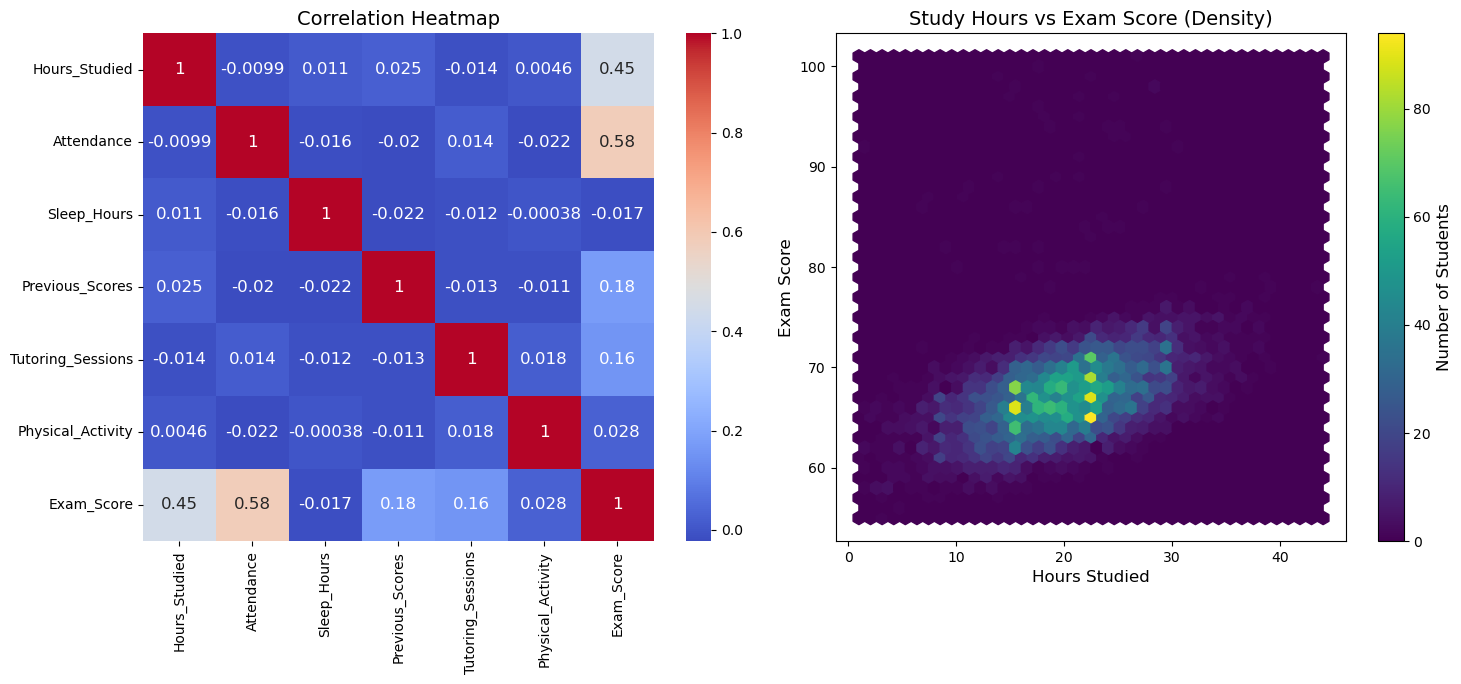

In [9]:
plt.figure(figsize=(15,7))

# Heatmap 
plt.subplot(1,2,1)
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")

# Hexbin 
plt.subplot(1,2,2)   

hb = plt.hexbin(df["Hours_Studied"], df["Exam_Score"], gridsize=40, cmap="viridis")
plt.colorbar(hb, label="Number of Students")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score (Density)")

plt.tight_layout()
plt.show()